In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

In [2]:
data=pd.read_csv(r"C:\Users\Pravalika.b\Downloads\Online Retail.csv")
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [5]:
print("Dataset shape:", data.shape)

Dataset shape: (541909, 8)


In [6]:
print("\nFirst 5 rows:")
print(data.head())


First 5 rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

    InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/10 8:26       2.55     17850.0  United Kingdom  
1  12/1/10 8:26       3.39     17850.0  United Kingdom  
2  12/1/10 8:26       2.75     17850.0  United Kingdom  
3  12/1/10 8:26       3.39     17850.0  United Kingdom  
4  12/1/10 8:26       3.39     17850.0  United Kingdom  


In [7]:
print("\nColumn names:")
print(data.columns.tolist())


Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


### Data Cleaning

In [8]:
print("\nMissing values:")
print(data.isnull().sum())



Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [9]:
data=data.dropna(subset=['CustomerID'])

In [10]:
data["CustomerID"]=data["CustomerID"].astype(str)

In [11]:
data["InvoiceDate"]=pd.to_datetime(data["InvoiceDate"])

C:\Users\Pravalika.b\AppData\Local\Temp\ipykernel_15044\1771032911.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["InvoiceDate"]=pd.to_datetime(data["InvoiceDate"])


In [12]:
data=data[-data["InvoiceNo"].astype(str).str.startswith('C')]

In [13]:
data=data[data['Quantity'] > 0]

In [14]:
data=data[data['UnitPrice'] > 0]

In [16]:
print("\nDataset after cleaning:")
print("shape:",data.shape)


Dataset after cleaning:
shape: (397884, 8)


### Create Revenue

In [18]:
data["Revenue"]=data["Quantity"]*data["UnitPrice"]
print("\nRevenue created sucessfully")
print(data[["Quantity","UnitPrice","Revenue"]].head())


Revenue created sucessfully
   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


In [19]:
refernce_date = data["InvoiceDate"].max() + pd.DateOffset(days=1)
print("\nReference date:", refernce_date)


Reference date: 2011-12-10 12:50:00


### Calculate RFM

In [20]:
rfm=data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (refernce_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

In [21]:
rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'Revenue': 'Monetary'}, inplace=True)
print("\n RFM Table:")
print(rfm.head())


 RFM Table:
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


In [22]:
print("\nRFM Statistics:")
print(rfm.describe())


RFM Statistics:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


In [ ]:
rfm["R_Score"]=pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1], duplicates='drop')
rfm["F_Score"]=pd.qcut(rfm['Frequency'].rank(method="first"),5,labels=[1,2,3,4,5])
rfm["M_Score"]=pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5], duplicates='drop')

In [25]:
rfm["R_Score"]=rfm["R_Score"].astype(int)
rfm["F_Score"]=rfm["F_Score"].astype(int)
rfm["M_Score"]=rfm["M_Score"].astype(int)

In [26]:
rfm["RFM"]=rfm["R_Score"].astype(str)+rfm["F_Score"].astype(str)+rfm["M_Score"].astype(str)
print("\nRFM Scores:")
print(rfm.head())


RFM Scores:
            Recency  Frequency  Monetary  R_Score  F_Score  M_Score  RFM
CustomerID                                                              
12346.0         326          1  77183.60        1        1        5  115
12347.0           2          7   4310.00        5        5        5  555
12348.0          75          4   1797.24        2        4        4  244
12349.0          19          1   1757.55        4        1        4  414
12350.0         310          1    334.40        1        1        2  112


In [27]:
rfm_clustering=rfm[['Recency','Frequency','Monetary']].copy()

In [29]:
rfm_log=np.log1p(rfm_clustering)

In [30]:
scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(rfm_log)

In [33]:
inertial=[]
k_range=range(2,9)
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(rfm_scaled)
    inertial.append(kmeans.inertia_)    

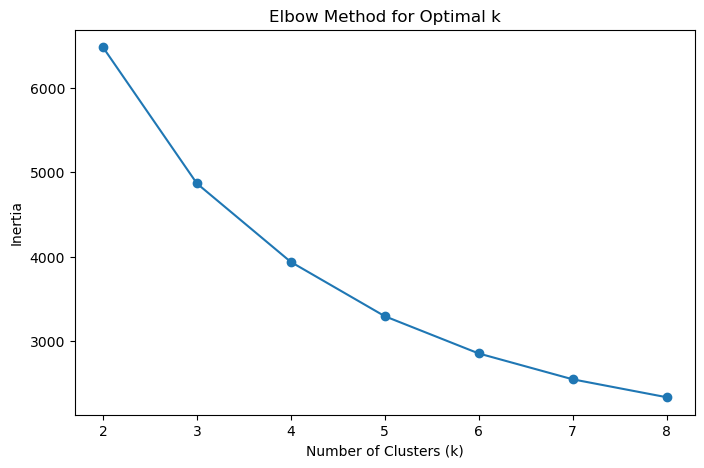

In [34]:
plt.figure(figsize=(8,5))
plt.plot(k_range,inertial,marker='o')   
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.show()

In [38]:
silhouette_scores=[]
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=kmeans.fit_predict(rfm_scaled)
    score=silhouette_score(rfm_scaled,labels)
    silhouette_scores.append(score)
    print("\nSilhouette Scores:")
    for k, score in zip(k_range, silhouette_scores):
        print(f"Number of Clusters (k): {k}, Silhouette Score: {score:.4f}")


Silhouette Scores:
Number of Clusters (k): 2, Silhouette Score: 0.4329

Silhouette Scores:
Number of Clusters (k): 2, Silhouette Score: 0.4329
Number of Clusters (k): 3, Silhouette Score: 0.3365

Silhouette Scores:
Number of Clusters (k): 2, Silhouette Score: 0.4329
Number of Clusters (k): 3, Silhouette Score: 0.3365
Number of Clusters (k): 4, Silhouette Score: 0.3371

Silhouette Scores:
Number of Clusters (k): 2, Silhouette Score: 0.4329
Number of Clusters (k): 3, Silhouette Score: 0.3365
Number of Clusters (k): 4, Silhouette Score: 0.3371
Number of Clusters (k): 5, Silhouette Score: 0.3161

Silhouette Scores:
Number of Clusters (k): 2, Silhouette Score: 0.4329
Number of Clusters (k): 3, Silhouette Score: 0.3365
Number of Clusters (k): 4, Silhouette Score: 0.3371
Number of Clusters (k): 5, Silhouette Score: 0.3161
Number of Clusters (k): 6, Silhouette Score: 0.3133

Silhouette Scores:
Number of Clusters (k): 2, Silhouette Score: 0.4329
Number of Clusters (k): 3, Silhouette Score: 0.3

In [108]:
best_k=5
print("\nBest number of clusters:", best_k)


Best number of clusters: 5


In [109]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(rfm_scaled)

print(cluster_labels[:10])
rfm["Cluster"] = cluster_labels


[4 1 4 0 2 1 2 4 2 1]


In [110]:
rfm.columns

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster',
       'Cluster_Segment', 'R_Score', 'F_Score', 'M_Score', 'RFM'],
      dtype='object')

In [111]:
print(rfm.columns)
print(rfm.shape)

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster',
       'Cluster_Segment', 'R_Score', 'F_Score', 'M_Score', 'RFM'],
      dtype='object')
(4338, 10)


In [112]:
cluster_profile=rfm.groupby("Cluster").agg({
    'Recency': 'mean',  
    'Frequency': 'mean',
    'Monetary': 'mean',
    "CustomerID": 'count'
    }).rename(columns={"CustomerID":"Customer_Count"})
print("\nCluster Profile:")
print(cluster_profile)


Cluster Profile:
            Recency  Frequency      Monetary  Customer_Count
Cluster                                                     
0         26.988249   1.613396    389.042844             851
1         17.547669   5.797669   2168.931155             944
2        210.147679   1.212658    277.204811            1185
3         11.189504  20.626822  13780.075510             343
4        103.142857   3.127094   1455.968308            1015


In [113]:
cluster_profile["R_Rank"]=(cluster_profile["Recency"].rank(ascending=False))
cluster_profile["F_Rank"]=(cluster_profile["Frequency"].rank(ascending=True))
cluster_profile["M_Rank"]=(cluster_profile["Monetary"].rank(ascending=True))
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])

rfm["RFM"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)
cluster_profile["RFM_Score"]=(cluster_profile["R_Rank"]+cluster_profile["F_Rank"]+cluster_profile["M_Rank"])


In [114]:
cluster_order=cluster_profile.sort_values("RFM_Score",ascending=False).index.tolist()

In [130]:
segment_names=["Champions","Loyal Customers","Potential Loyalist","New Customers","Promising","Need Attention","About To Sleep","At Risk","Hibernating"]    
segment_names=segment_names[:best_k]
cluster_to_segment={
    0:"New Customers",
    1:"Loyal Customers",
    2:"Lost Customers",
    3:"champions",
    4:"At Risk"
}
rfm["Cluster_Segment"]=rfm["Cluster"].map(cluster_to_segment)

In [131]:
print("\nFINAL CLUSTER PROFILE:")
print(cluster_profile[["Recency","Frequency","Monetary","Customer_Count","RFM_Score"]].round(2))


FINAL CLUSTER PROFILE:
         Recency  Frequency  Monetary  Customer_Count  RFM_Score
Cluster                                                         
0          26.99       1.61    389.04             851        7.0
1          17.55       5.80   2168.93             944       12.0
2         210.15       1.21    277.20            1185        3.0
3          11.19      20.63  13780.08             343       15.0
4         103.14       3.13   1455.97            1015        8.0


In [132]:
final_rfm=rfm.reset_index()
final_rfm=rfm[["CustomerID","Recency","Frequency","Monetary","R_Score","F_Score","M_Score","RFM","Cluster","Cluster_Segment"]]
print("\nFinal RFM Customer Table:")
print(final_rfm.head(10))


Final RFM Customer Table:
  CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score  RFM  \
0    12346.0      325          1  77183.60       1       1       5  115   
1    12347.0        1          7   4310.00       5       5       5  555   
2    12348.0       74          4   1797.24       2       4       4  244   
3    12349.0       18          1   1757.55       4       1       4  414   
4    12350.0      309          1    334.40       1       1       2  112   
5    12352.0       35          8   2506.04       3       5       5  355   
6    12353.0      203          1     89.00       1       1       1  111   
7    12354.0      231          1   1079.40       1       1       4  114   
8    12355.0      213          1    459.40       1       1       2  112   
9    12356.0       22          3   2811.43       4       3       5  435   

   Cluster  Cluster_Segment  
0        4          At Risk  
1        1  Loyal Customers  
2        4          At Risk  
3        0    New Customers

In [133]:
print(final_rfm.columns)

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score',
       'M_Score', 'RFM', 'Cluster', 'Cluster_Segment'],
      dtype='object')


In [134]:
segment_summary=final_rfm.groupby("Cluster_Segment").agg({
    "CustomerID":"count",
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
}).rename(columns={"CustomerID":"Customer_Count"})
print("\nCustomer Segment Summary:")
print(segment_summary)


Customer Segment Summary:
                 Customer_Count     Recency  Frequency      Monetary
Cluster_Segment                                                     
At Risk                    1015  103.142857   3.127094   1455.968308
Lost Customers             1185  210.147679   1.212658    277.204811
Loyal Customers             944   17.547669   5.797669   2168.931155
New Customers               851   26.988249   1.613396    389.042844
champions                   343   11.189504  20.626822  13780.075510


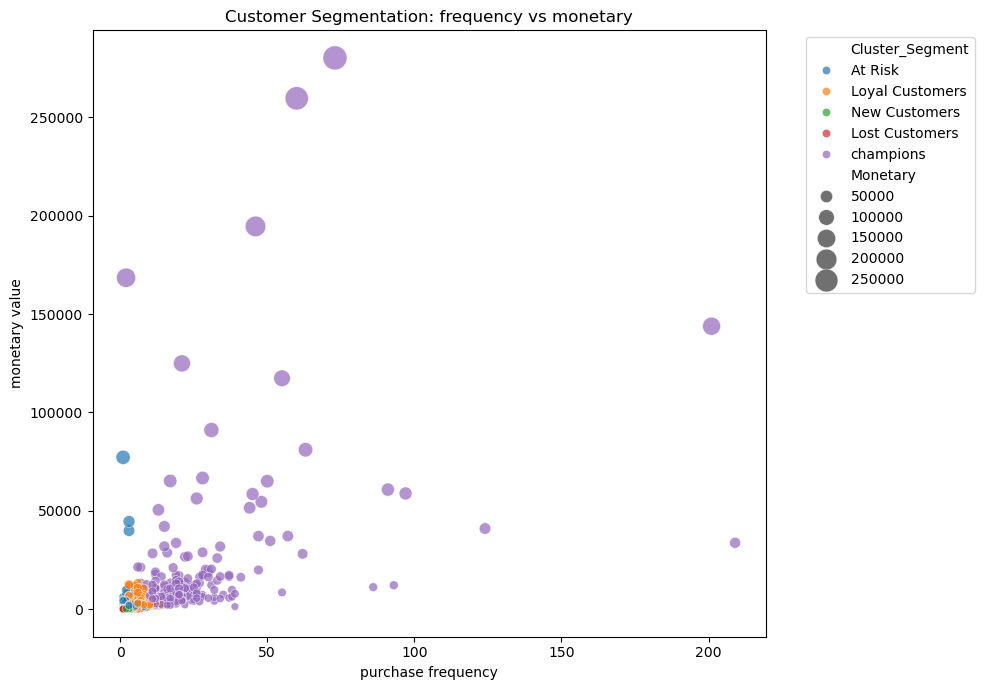

In [135]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=final_rfm, x="Frequency", y="Monetary", hue="Cluster_Segment",size="Monetary",sizes=(30,300),alpha=0.7)
plt.title("Customer Segmentation: frequency vs monetary")
plt.xlabel("purchase frequency")
plt.ylabel("monetary value")
plt.legend(bbox_to_anchor=(1.05,1),loc="upper left")
plt.tight_layout()
plt.show()

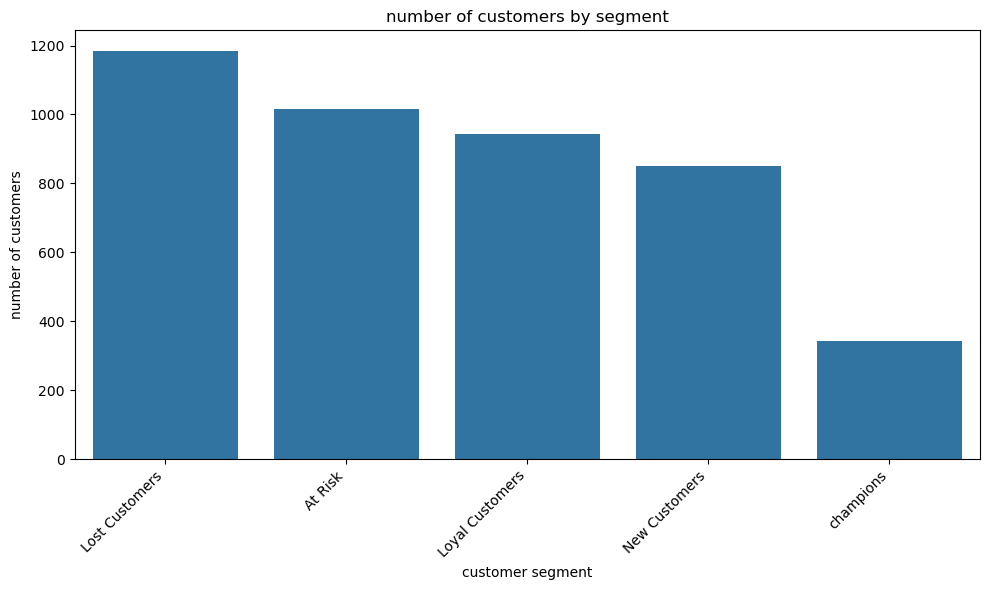

In [136]:
segment_counts=(final_rfm["Cluster_Segment"].value_counts())
plt.figure(figsize=(10,6))
sns.barplot(x=segment_counts.index, y=segment_counts.values)
plt.title("number of customers by segment")
plt.xlabel("customer segment")
plt.ylabel("number of customers")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

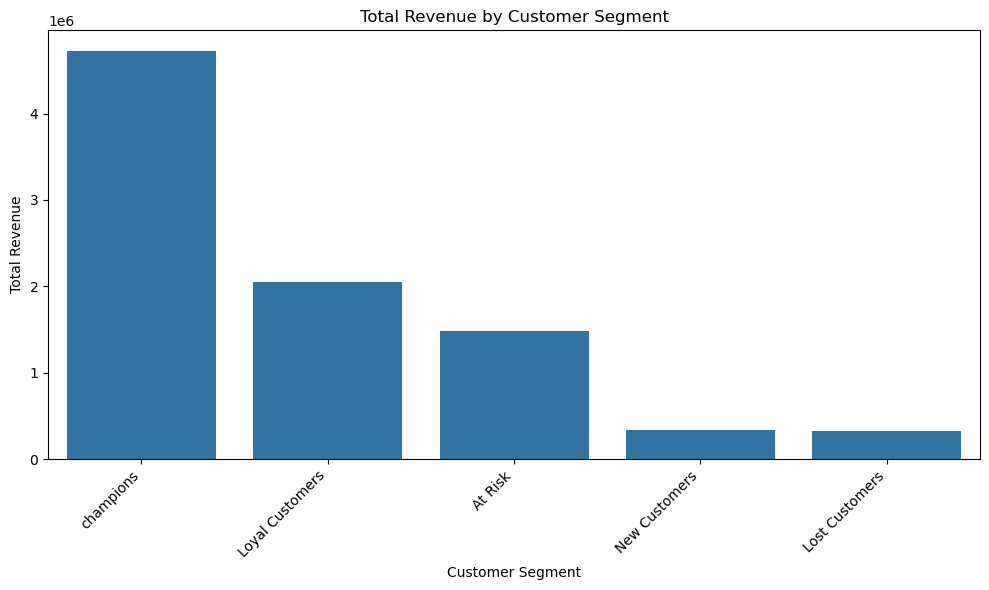

In [137]:
revenue_by_segment=final_rfm.groupby("Cluster_Segment")["Monetary"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))  
sns.barplot(x=revenue_by_segment.index, y=revenue_by_segment.values)
plt.title("Total Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

In [138]:
final_rfm.to_csv("RFM_Customer_Scores.csv",index=False)

In [139]:
segment_summary.to_csv("Customer_Segment_Summary.csv")

In [140]:
cluster_profile.to_csv("cluster_profile.csv")

In [141]:
print("1. RFM_customer_Scores.csv")
print("2. Customer_Segment_Summary.csv")
print("3. cluster_profile.csv")

1. RFM_customer_Scores.csv
2. Customer_Segment_Summary.csv
3. cluster_profile.csv
